In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

TEXTURE_FEATURES_3D = [
    # GLCM features
    "3GLCM_ACOR", "3GLCM_ASM", "3GLCM_CLUPROM", "3GLCM_CLUSHADE", "3GLCM_CLUTEND",
    "3GLCM_CONTRAST", "3GLCM_CORRELATION", "3GLCM_DIFAVE", "3GLCM_DIFENTRO", "3GLCM_DIFVAR",
    "3GLCM_DIS", "3GLCM_ENERGY", "3GLCM_ENTROPY", "3GLCM_HOM1", "3GLCM_HOM2",
    "3GLCM_ID", "3GLCM_IDN", "3GLCM_IDM", "3GLCM_IDMN", "3GLCM_INFOMEAS1", "3GLCM_INFOMEAS2",
    "3GLCM_IV", "3GLCM_JAVE", "3GLCM_JE", "3GLCM_JMAX", "3GLCM_JVAR",
    "3GLCM_SUMAVERAGE", "3GLCM_SUMENTROPY", "3GLCM_SUMVARIANCE", "3GLCM_VARIANCE",
    "3GLCM_ASM_AVE", "3GLCM_ACOR_AVE", "3GLCM_CLUPROM_AVE", "3GLCM_CLUSHADE_AVE",
    "3GLCM_CLUTEND_AVE", "3GLCM_CONTRAST_AVE", "3GLCM_CORRELATION_AVE",
    "3GLCM_DIFAVE_AVE", "3GLCM_DIFENTRO_AVE", "3GLCM_DIFVAR_AVE", "3GLCM_DIS_AVE",
    "3GLCM_ENERGY_AVE", "3GLCM_ENTROPY_AVE", "3GLCM_HOM1_AVE", "3GLCM_ID_AVE",
    "3GLCM_IDN_AVE", "3GLCM_IDM_AVE", "3GLCM_IDMN_AVE", "3GLCM_IV_AVE",
    "3GLCM_JAVE_AVE", "3GLCM_JE_AVE", "3GLCM_INFOMEAS1_AVE", "3GLCM_INFOMEAS2_AVE",
    "3GLCM_VARIANCE_AVE", "3GLCM_JMAX_AVE", "3GLCM_JVAR_AVE",
    "3GLCM_SUMAVERAGE_AVE", "3GLCM_SUMENTROPY_AVE", "3GLCM_SUMVARIANCE_AVE",

    # GLRLM features
    "3GLRLM_SRE", "3GLRLM_LRE", "3GLRLM_GLN", "3GLRLM_GLNN", "3GLRLM_RLN", "3GLRLM_RLNN",
    "3GLRLM_RP", "3GLRLM_GLV", "3GLRLM_RV", "3GLRLM_RE", "3GLRLM_LGLRE", "3GLRLM_HGLRE",
    "3GLRLM_SRLGLE", "3GLRLM_SRHGLE", "3GLRLM_LRLGLE", "3GLRLM_LRHGLE",
    "3GLRLM_SRE_AVE", "3GLRLM_LRE_AVE", "3GLRLM_GLN_AVE", "3GLRLM_GLNN_AVE",
    "3GLRLM_RLN_AVE", "3GLRLM_RLNN_AVE", "3GLRLM_RP_AVE", "3GLRLM_GLV_AVE",
    "3GLRLM_RV_AVE", "3GLRLM_RE_AVE", "3GLRLM_LGLRE_AVE", "3GLRLM_HGLRE_AVE",
    "3GLRLM_SRLGLE_AVE", "3GLRLM_SRHGLE_AVE", "3GLRLM_LRLGLE_AVE", "3GLRLM_LRHGLE_AVE",

    # GLSZM features
    "GLSZM_SAE", "GLSZM_LAE", "GLSZM_GLN", "GLSZM_GLNN", "GLSZM_SZN", "GLSZM_SZNN",
    "GLSZM_ZP", "GLSZM_GLV", "GLSZM_ZV", "GLSZM_ZE", "GLSZM_LGLZE", "GLSZM_HGLZE",
    "GLSZM_SALGLE", "GLSZM_SAHGLE", "GLSZM_LALGLE", "GLSZM_LAHGLE",

    # GLDM features
    "3GLDM_SDE", "3GLDM_LDE", "3GLDM_GLN", "3GLDM_DN", "3GLDM_DNN", "3GLDM_GLV",
    "3GLDM_DV", "3GLDM_DE", "3GLDM_LGLE", "3GLDM_HGLE", "3GLDM_SDLGLE", "3GLDM_SDHGLE",
    "3GLDM_LDLGLE", "3GLDM_LDHGLE",

    # GLDZM features
    "3GLDZM_SDE", "3GLDZM_LDE", "3GLDZM_LGLZE", "3GLDZM_HGLZE", "3GLDZM_SDLGLE",
    "3GLDZM_SDHGLE", "3GLDZM_LDLGLE", "3GLDZM_LDHGLE", "3GLDZM_GLNU", "3GLDZM_GLNUN",
    "3GLDZM_ZDNU", "3GLDZM_ZDNUN", "3GLDZM_ZP", "3GLDZM_GLM", "3GLDZM_GLV",
    "3GLDZM_ZDM", "3GLDZM_ZDV", "3GLDZM_ZDE",

    # NGLDM features
    "3NGLDM_LDE", "3NGLDM_HDE", "3NGLDM_LGLCE", "3NGLDM_HGLCE", "3NGLDM_LDLGLE",
    "3NGLDM_LDHGLE", "3NGLDM_HDLGLE", "3NGLDM_HDHGLE", "3NGLDM_GLNU", "3NGLDM_GLNUN",
    "3NGLDM_DCNU", "3NGLDM_DCNUN", "3NGLDM_DCP", "3NGLDM_GLM", "3NGLDM_GLV",
    "3NGLDM_DCM", "3NGLDM_DCV", "3NGLDM_DCENT", "3NGLDM_DCENE",

    # NGTDM features
    "3NGTDM_COARSENESS", "3NGTDM_CONTRAST", "3NGTDM_BUSYNESS", "3NGTDM_COMPLEXITY",
    "3NGTDM_STRENGTH",
]

In [2]:

def read_features(features_dir: str) -> pd.DataFrame:
    """Read features from a directory.
    
    Args:
        features_dir: Directory containing features
        
    Returns:
        DataFrame containing all features
    """
    features = []
    for file in os.listdir(features_dir):
        df = pd.read_csv(os.path.join(features_dir, file))
        features.append(df)
    return pd.concat(features, ignore_index=True)

In [3]:
original_features_dir = "../../datasets/ADNI/original_features"
normalized_features_dir = "../../datasets/ADNI/nyul_normalized_features"
plots_path = "images_ADNI_Nyul"

original_features = read_features(original_features_dir)
normalized_features = read_features(normalized_features_dir)

print(original_features.head())
print(normalized_features.head())




                                     intensity_image  \
0  ADNI_123_S_0108_MR_MPR____N3__Scaled_2_Br_2008...   
1  ADNI_123_S_0162_MR_MPR____N3__Scaled_2_Br_2008...   
2  ADNI_005_S_0223_MR_MPR__GradWarp__B1_Correctio...   
3  ADNI_005_S_0223_MR_MPR__GradWarp__B1_Correctio...   
4  ADNI_007_S_0101_MR_MPR__GradWarp__B1_Correctio...   

                                          mask_image  ROI_label      3COV  \
0  ADNI_123_S_0108_MR_MPR____N3__Scaled_2_Br_2008...        1.0  0.163610   
1  ADNI_123_S_0162_MR_MPR____N3__Scaled_2_Br_2008...        1.0  0.162649   
2  ADNI_005_S_0223_MR_MPR__GradWarp__B1_Correctio...        1.0  0.201992   
3  ADNI_005_S_0223_MR_MPR__GradWarp__B1_Correctio...        1.0  0.168293   
4  ADNI_007_S_0101_MR_MPR__GradWarp__B1_Correctio...        1.0  0.166701   

   3COVERED_IMAGE_INTENSITY_RANGE       3ENERGY  3ENTROPY  3EXCESS_KURTOSIS  \
0                             1.0  1.201864e+11  3.167518          1.650244   
1                             1.0  5.56998

In [4]:
def select_features(features: pd.DataFrame, feature_list: list) -> pd.DataFrame:
    """Select features from a DataFrame.
    
    Args:
        features: DataFrame containing features
        feature_list: List of feature names to select
        
    Returns:
        DataFrame containing selected features
    """ 
    return features[feature_list]


original_features = select_features(original_features, TEXTURE_FEATURES_3D)
normalized_features = select_features(normalized_features, TEXTURE_FEATURES_3D)

print(original_features.head())
print(normalized_features.head())

   3GLCM_ACOR  3GLCM_ASM  3GLCM_CLUPROM  3GLCM_CLUSHADE  3GLCM_CLUTEND  \
0   72.221614   0.838703  888646.624115    14196.206203     259.375711   
1   39.534310   0.900007  551240.549325     8638.475899     149.554793   
2   38.860359   0.888737  481853.760603     7848.712056     143.735800   
3   20.326982   0.945421  300157.817037     4607.095774      77.195786   
4   43.017345   0.864069  393610.106349     7342.180394     153.846928   

   3GLCM_CONTRAST  3GLCM_CORRELATION  3GLCM_DIFAVE  3GLCM_DIFENTRO  \
0       14.810681           0.891966      0.671823        0.668387   
1       13.318696           0.836454      0.555701        0.470499   
2       10.903649           0.858986      0.537775        0.510897   
3        7.355622           0.826027      0.307196        0.267051   
4        9.204259           0.887100      0.501424        0.557371   

   3GLCM_DIFVAR  ...  3NGLDM_GLV  3NGLDM_DCM  3NGLDM_DCV  3NGLDM_DCENT  \
0     14.359335  ...   11.293263   22.919200   27.957819    

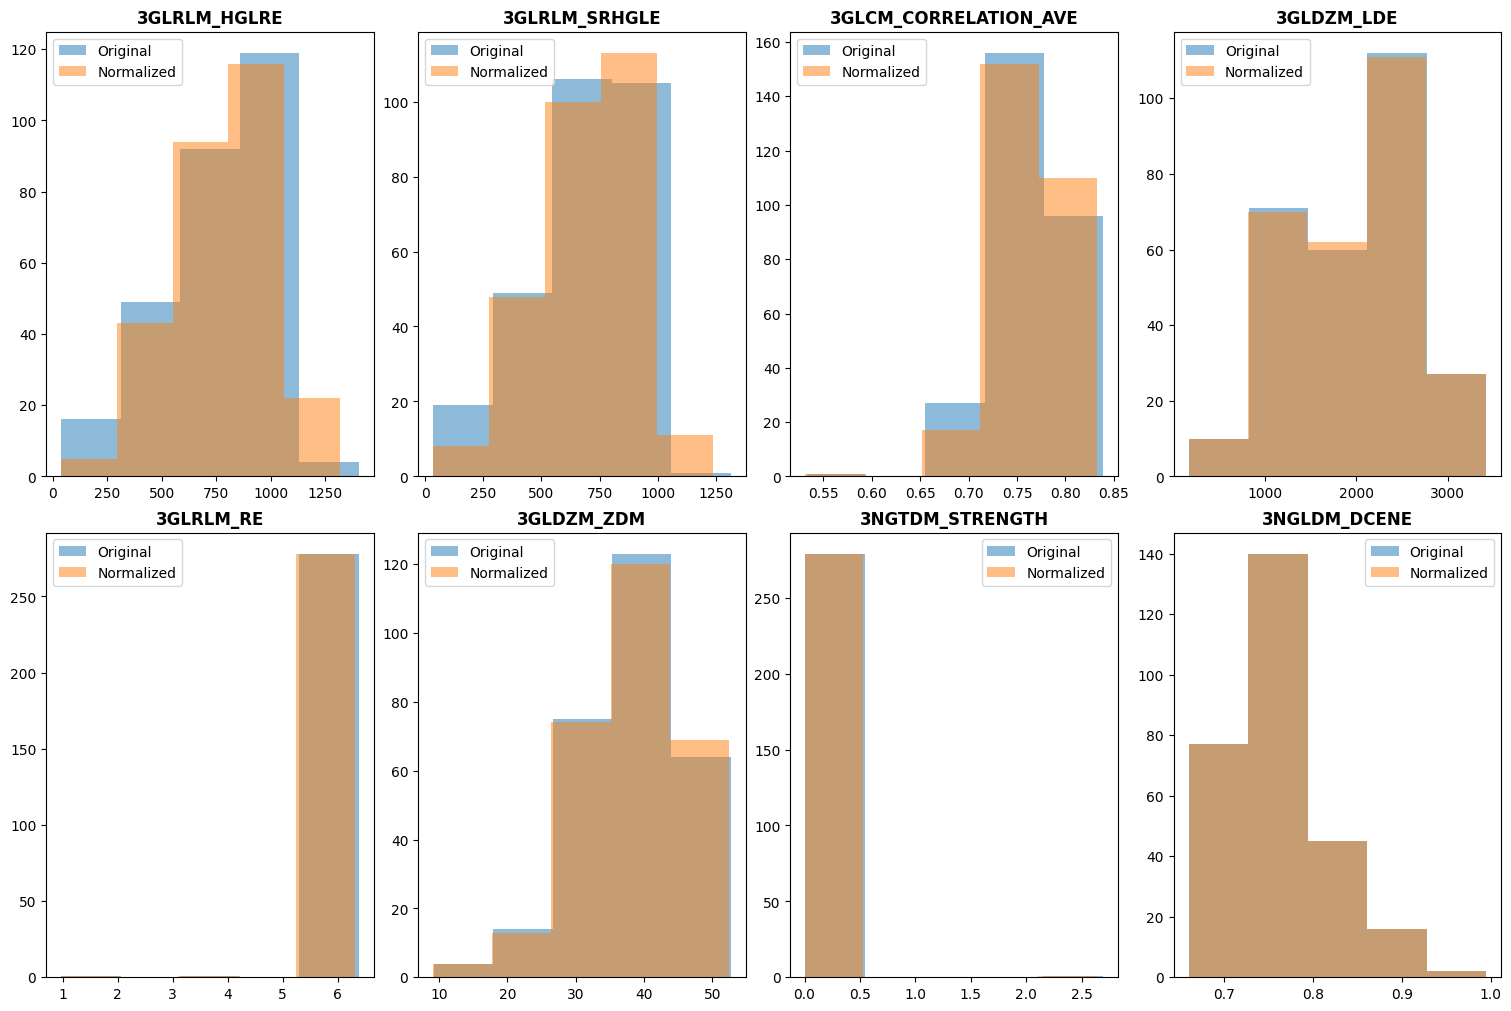

In [5]:
import matplotlib.pyplot as plt
num_bins = 5
fig, axs = plt.subplots(2, 4, figsize=(15, 10), constrained_layout=True)
cnt = 0 
sample_features = ['3GLRLM_HGLRE', '3GLRLM_SRHGLE', '3GLCM_CORRELATION_AVE', '3GLDZM_LDE', '3GLRLM_RE', '3GLDZM_ZDM', '3NGTDM_STRENGTH', '3NGLDM_DCENE']
for feature in sample_features:
    # print(f"Shape: {data.shape}, Values > {filter_threshold}: {len(filtered_data)}")

    axs[cnt//4, cnt%4].hist(original_features[feature],  bins=num_bins, alpha=0.5, label='Original')
    axs[cnt//4, cnt%4].hist(normalized_features[feature], bins=num_bins, alpha=0.5, label='Normalized')
    axs[cnt//4, cnt%4].set_title(feature, fontsize=12, fontweight='bold')
    # axs[cnt//3, cnt%3].set_xlabel('Signal Intensity')
    # axs[cnt//3, cnt%3].set_ylabel('Frequency')
    axs[cnt//4, cnt%4].legend()
    cnt += 1

# plt.legend()
plt.savefig(f"{plots_path}/3D_texture_features_hist.png")
plt.show()

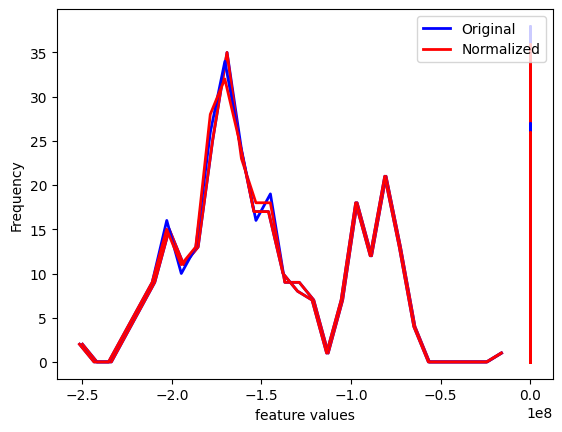

In [10]:
num_bins = 30
TEXTURE_FEATURES_3D_positive = [feature for feature in TEXTURE_FEATURES_3D if original_features[feature].min() > 0]
TEXTURE_FEATURES_3D_negative = list(set(TEXTURE_FEATURES_3D) - set(TEXTURE_FEATURES_3D_positive))
for idx, feature in enumerate(TEXTURE_FEATURES_3D_negative):
    # plot the histogram of the original image
    # print(original_features[feature])
    hist_values, bin_edges = np.histogram(original_features[feature], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='blue',  label='Original' if idx == 0 else "")

    # plot the histogram of the normalized image
    hist_values, bin_edges = np.histogram(normalized_features[feature], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='red',  label='Normalized' if idx == 0 else "")

    
# plt.title(scan_dates[idx], fontsize=12, fontweight='bold')
# plt.xlim(0, 5000)
# plt.ylim(0, 5e5)
plt.xlabel('feature values')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.savefig(f'{plots_path}/feature_histogram_comparison_negative.png')
plt.show()

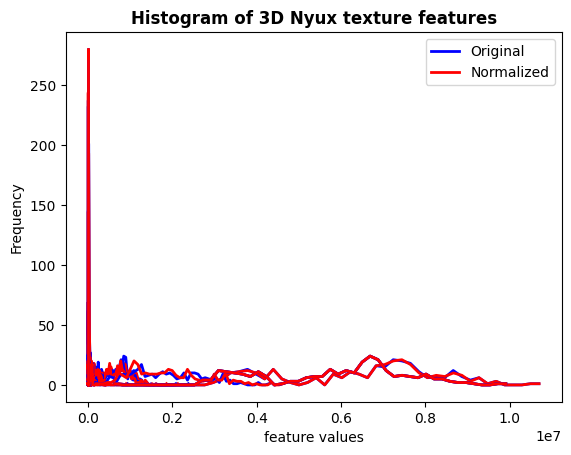

In [15]:

num_bins = 50 
for idx, feature in enumerate(TEXTURE_FEATURES_3D_positive):
    # plot the histogram of the original image
    hist_values, bin_edges = np.histogram(original_features[feature], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='blue', label='Original' if idx == 0 else "")

    # plot the histogram of the normalized image
    hist_values, bin_edges = np.histogram(normalized_features[feature], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='red', label='Normalized' if idx == 0 else "")

    
plt.title("Histogram of 3D Nyux texture features", fontsize=12, fontweight='bold')
# plt.xlim(0, 5000)
# plt.ylim(0, 5e5)
plt.xlabel('feature values')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.savefig(f'{plots_path}/feature_histogram_comparison_positive.png')
plt.show()

In [16]:
# Calculate significance for a single feature
def f_test_variance(feature_name, original_df, normalized_df, alpha=0.05) -> bool:
    var_original = np.var(original_df[feature_name], ddof=1)
    var_normalized = np.var(normalized_df[feature_name], ddof=1)
    
    f_stat = var_original / var_normalized
    n1, n2 = len(original_df), len(normalized_df)
    dfn, dfd = n1 - 1, n2 - 1
    # Calculate p-value for two-tailed F-test
    p_value = 2 * min(stats.f.cdf(f_stat, dfn, dfd), 1 - stats.f.cdf(f_stat, dfn, dfd))
    
    # print(f"Feature: {feature_name}")
    # print(f"Original variance: {var_original:.6f}")
    # print(f"Normalized variance: {var_normalized:.6f}")
    # print(f"F-statistic: {f_stat:.6f}")
    # print(f"p-value: {p_value:.6f}")
    # print("Interpretation:", end=" ")
    if p_value < alpha:
        if f_stat > 1:
            print("Original has significantly higher variance")
        else:
            print("Normalized has significantly higher variance")
        return True
    else:
        print("No significant difference in variances")


# Example usage for first few features
significant_features = []
for feature in TEXTURE_FEATURES_3D:
    if f_test_variance(feature, original_features, normalized_features):
        significant_features.append(feature)
print(f"Number of features with a significant difference in variance: {len(significant_features)}, significant features: {significant_features}")

No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference

/var/folders/1_/hbvlzgk167j9cnkp3c_fg7w05_1gfg/T/ipykernel_41538/673664096.py:6: RuntimeWarning: invalid value encountered in scalar divide
  f_stat = var_original / var_normalized


In [17]:
def compare_features_wilcoxon(original_df: pd.DataFrame, normalized_df: pd.DataFrame, 
                              feature_list: list[str], alpha: float = 0.05) -> pd.DataFrame:
    """Perform Wilcoxon signed-rank test to compare original and normalized features."""
    results = []
    
    for feature in feature_list:
        if feature in original_df.columns and feature in normalized_df.columns:
            # Perform Wilcoxon test
            stat, p_value = stats.wilcoxon(original_df[feature], 
                                         normalized_df[feature],
                                         alternative='two-sided')
            
            # Calculate effect size
            n = len(original_df[feature])
            z_score = stats.norm.ppf(p_value / 2)
            
            # r < 0.1: Negligible effect
            # 0.1 ≤ r < 0.3: Small effect
            # 0.3 ≤ r < 0.5: Medium effect
            # r ≥ 0.5: Large effect
            effect_size = abs(z_score) / np.sqrt(n)
            
            # Determine direction
            mean_diff = np.mean(original_df[feature] - normalized_df[feature])
            direction = "higher" if mean_diff > 0 else "lower"
            
            results.append({
                'feature_name': feature,
                'statistic': stat,
                'p_value': p_value,
                'significant': p_value < alpha,
                'effect_size': effect_size,
                'original_vs_normalized': f"Original {direction} than normalized"
            })
    
    return pd.DataFrame(results).sort_values('p_value')

# Run the comparison
wilcoxon_results = compare_features_wilcoxon(original_features, normalized_features, 
                                           TEXTURE_FEATURES_3D)

# Show results
print("\nFeatures with significant differences (p < 0.05):")
significant = wilcoxon_results[wilcoxon_results['significant']]
print(f" Number of significant features: {significant.shape[0]}")
print(significant['feature_name'].tolist())
#print(significant[['featur e_name', 'p_value', 'effect_size', 'original_vs_normalized']].head())



Features with significant differences (p < 0.05):
 Number of significant features: 82
['3GLRLM_SRLGLE', '3GLRLM_SRLGLE_AVE', '3GLDZM_LDE', '3GLDZM_ZDM', '3GLDZM_LDLGLE', '3GLCM_CORRELATION_AVE', '3GLDM_LDLGLE', '3NGTDM_COMPLEXITY', '3GLDZM_LGLZE', '3GLCM_CORRELATION', '3GLRLM_LRLGLE', '3GLRLM_LRE', '3GLDM_LGLE', 'GLSZM_LGLZE', '3NGLDM_HDLGLE', '3GLRLM_LRE_AVE', '3GLRLM_LRLGLE_AVE', 'GLSZM_SALGLE', '3NGLDM_GLV', 'GLSZM_LAE', 'GLSZM_LAHGLE', '3NGLDM_LGLCE', '3GLDZM_LDHGLE', '3GLRLM_RV', '3GLDM_SDLGLE', 'GLSZM_ZV', '3GLRLM_RV_AVE', '3GLRLM_LGLRE', '3GLDZM_GLNUN', '3GLRLM_RP', 'GLSZM_GLNN', '3NGLDM_LDLGLE', '3GLRLM_GLNN', '3GLRLM_SRE', '3NGLDM_LDE', '3GLRLM_LGLRE_AVE', '3GLRLM_RP_AVE', 'GLSZM_SAE', '3GLRLM_SRE_AVE', '3GLRLM_GLNN_AVE', '3GLDM_LDE', '3GLDM_GLN', '3NGTDM_STRENGTH', '3NGTDM_COARSENESS', '3GLDZM_GLM', '3GLDZM_ZP', '3GLRLM_GLN_AVE', '3GLDM_LDHGLE', '3GLRLM_GLN', '3GLRLM_LRHGLE', '3GLCM_HOM2', '3GLRLM_RLNN_AVE', '3GLRLM_RLNN', '3GLDM_DV', '3GLRLM_LRHGLE_AVE', '3GLRLM_RLN', 'GLSZ

/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [18]:
def perform_anova_test(original_df: pd.DataFrame, normalized_df: pd.DataFrame, 
                      feature_list: list[str], alpha: float = 0.05) -> pd.DataFrame:
    """Perform one-way ANOVA test between original and normalized features.
    """
    results = []
    
    for feature in feature_list:
        if feature in original_df.columns and feature in normalized_df.columns:
            # Calculate basic statistics
            orig_mean = np.mean(original_df[feature])
            norm_mean = np.mean(normalized_df[feature])
            orig_var = np.var(original_df[feature], ddof=1)
            norm_var = np.var(normalized_df[feature], ddof=1)
            
            # Perform one-way ANOVA
            f_stat, p_value = stats.f_oneway(original_df[feature], 
                                           normalized_df[feature])
            
            # Calculate effect size (eta-squared)
            # η² = SSbetween / SStotal
            groups = [original_df[feature], normalized_df[feature]]
            grand_mean = np.mean([orig_mean, norm_mean])
            ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
            ss_total = sum((x - grand_mean)**2 for g in groups for x in g)
            eta_squared = ss_between / ss_total if ss_total != 0 else 0
            
            # The effect size thresholds (0.01, 0.06, 0.14) for eta-squared (η²)
            #  come from established statistical guidelines by Cohen (1988) and later researchers.
            if eta_squared < 0.01:
                effect_size_interp = "negligible"
            elif eta_squared < 0.06:
                effect_size_interp = "small"
            elif eta_squared < 0.14:
                effect_size_interp = "medium"
            else:
                effect_size_interp = "large"
            
            results.append({
                'feature_name': feature,
                'original_mean': orig_mean,
                'normalized_mean': norm_mean,
                'original_variance': orig_var,
                'normalized_variance': norm_var,
                'f_statistic': f_stat,
                'p_value': p_value,
                'significant': p_value < alpha,
                'eta_squared': eta_squared,
                'effect_size': effect_size_interp
            })
    
    results_df = pd.DataFrame(results)
    
    # Print summary
    print("ANOVA Test Results Summary:")
    print(f"Total features tested: {len(results_df)}")
    print(f"Features with significant differences: {sum(results_df['significant'])}")
    print("\nEffect size distribution:")
    print(results_df['effect_size'].value_counts())
    
    # Visualization of significant differences
    significant_results = results_df[results_df['significant']].sort_values('p_value')
    
 
    
    return results_df.sort_values('p_value')

# Run ANOVA analysis
anova_results = perform_anova_test(original_features, normalized_features, TEXTURE_FEATURES_3D)

significant = anova_results[anova_results['significant']]
print(f" Number of significant features: {significant.shape[0]}")


ANOVA Test Results Summary:
Total features tested: 163
Features with significant differences: 1

Effect size distribution:
effect_size
negligible    163
Name: count, dtype: int64
 Number of significant features: 1


/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


In [19]:
def calculate_kl_divergence(original_df: pd.DataFrame, normalized_df: pd.DataFrame, 
                           feature_list: list[str], n_bins: int = 10) -> pd.DataFrame:
    """Calculate KL divergence between original and normalized features."""
    results = []
    
    for feature in feature_list:
        if feature in original_df.columns and feature in normalized_df.columns:
          # Find common range for bins
            min_val = min(original_df[feature].min(), normalized_df[feature].min())
            max_val = max(original_df[feature].max(), normalized_df[feature].max())
            
            # Create common bins
            bins = np.linspace(min_val, max_val, n_bins + 1)
            
            # Use same bins for both histograms
            hist_orig, _ = np.histogram(original_df[feature], bins=bins, density=True)
            hist_norm, _ = np.histogram(normalized_df[feature], bins=bins, density=True)
            
            # Add small constant to avoid division by zero
            epsilon = 1e-10
            hist_orig = hist_orig + epsilon
            hist_norm = hist_norm + epsilon
            
            # Normalize
            hist_orig = hist_orig / hist_orig.sum()
            hist_norm = hist_norm / hist_norm.sum()
            
            # Calculate KL divergence
            kl_div = np.sum(hist_orig * np.log(hist_orig / hist_norm))
            
            results.append({
                'feature_name': feature,
                'kl_divergence': kl_div,
                'significant': kl_div > 1
            })
    
    return pd.DataFrame(results).sort_values('kl_divergence', ascending=False)



kl_results = calculate_kl_divergence(original_features, normalized_features, TEXTURE_FEATURES_3D)

print("top 10 features with highest distribution differences")
print(kl_results.sort_values('kl_divergence', ascending=False).head(10))
print("nyul 6000: ", kl_results['significant'].shape)


top 10 features with highest distribution differences
      feature_name  kl_divergence  significant
115     3GLDM_LGLE       0.895290        False
103   GLSZM_SALGLE       0.554168        False
145  3NGLDM_HDLGLE       0.417384        False
117   3GLDM_SDLGLE       0.403835        False
101    GLSZM_LGLZE       0.357377        False
18      3GLCM_IDMN       0.313651        False
143  3NGLDM_LDLGLE       0.312962        False
141   3NGLDM_LGLCE       0.303167        False
123   3GLDZM_LGLZE       0.272440        False
127  3GLDZM_LDLGLE       0.179904        False
nyul 6000:  (163,)


/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


/var/folders/1_/hbvlzgk167j9cnkp3c_fg7w05_1gfg/T/ipykernel_41538/720477906.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[cnt//num_cols, cnt%num_cols].boxplot(data, labels=['Original', 'Normalized'])
/var/folders/1_/hbvlzgk167j9cnkp3c_fg7w05_1gfg/T/ipykernel_41538/720477906.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[cnt//num_cols, cnt%num_cols].boxplot(data, labels=['Original', 'Normalized'])
/var/folders/1_/hbvlzgk167j9cnkp3c_fg7w05_1gfg/T/ipykernel_41538/720477906.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[cnt//num_cols, cnt%num_cols].boxplot(data, labels=['Original', 'Normalize

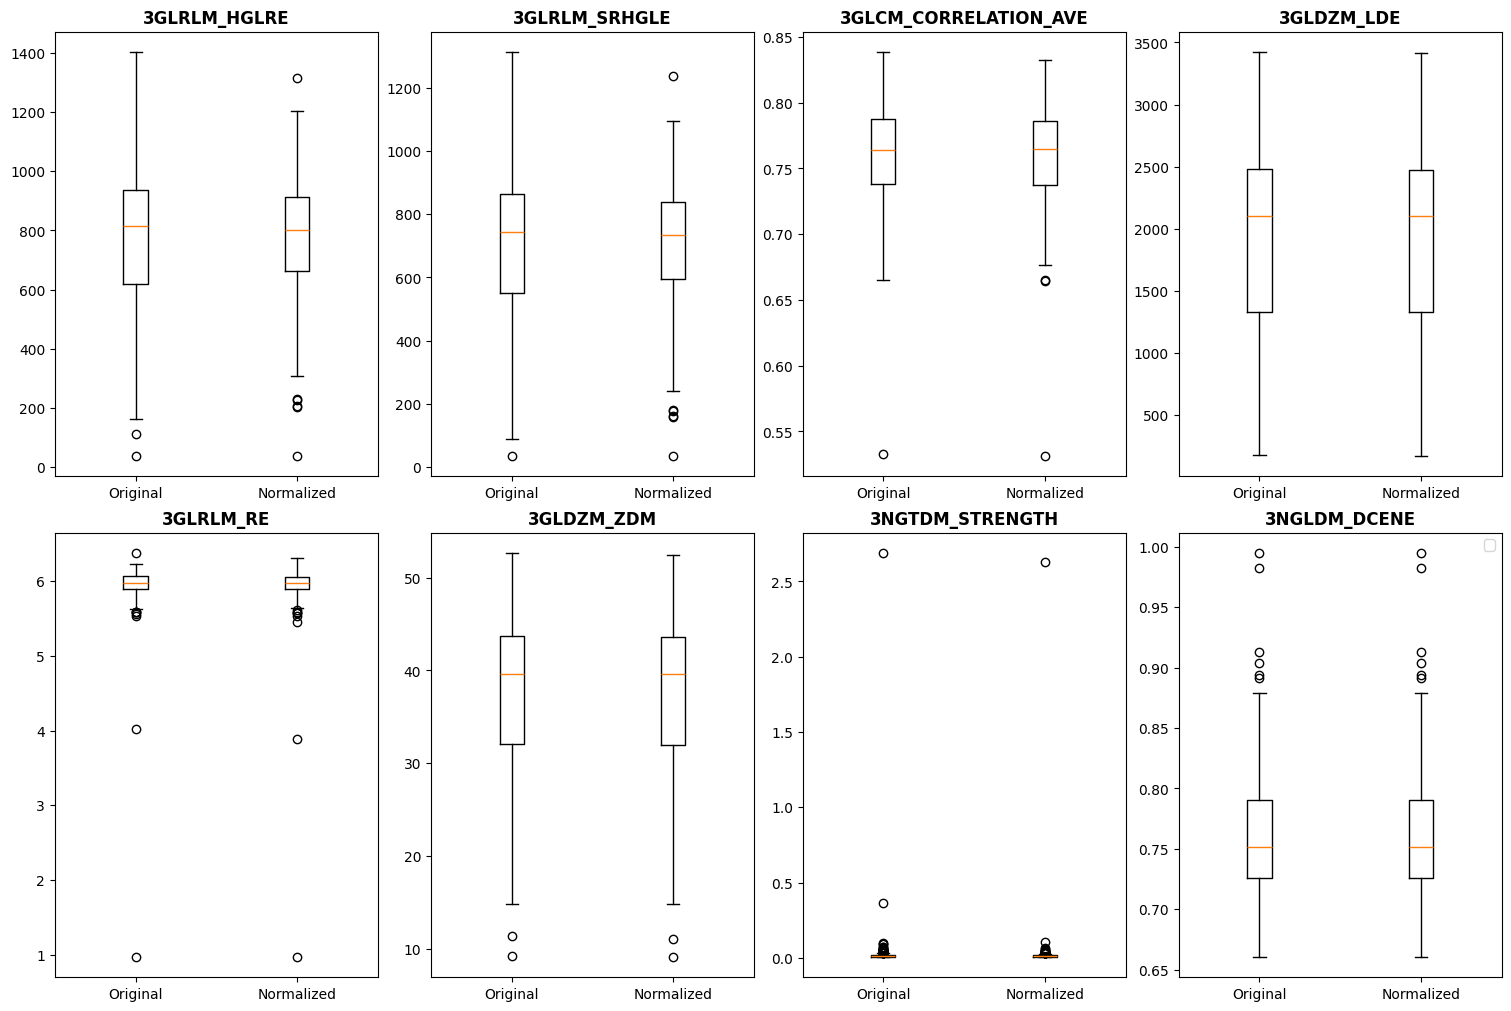

In [20]:
import matplotlib.pyplot as plt
num_bins = 7
num_cols = 4
fig, axs = plt.subplots(2, num_cols, figsize=(15, 10), constrained_layout=True)
cnt = 0 
# sample_features = ["3GLRLM_SRE", "3GLRLM_LRE", "3GLRLM_GLN", "3GLRLM_GLNN", "3NGTDM_COARSENESS", "3NGTDM_CONTRAST"]
# sample_features = ['3GLRLM_HGLRE', '3GLRLM_SRHGLE', '3GLRLM_HGLRE_AVE', '3GLRLM_GLNN', '3NGTDM_COARSENESS'] #, '3GLDM_LGLE', '3GLDM_HGLE', '3GLDM_SDLGLE', '3GLDZM_LGLZE', '3GLDZM_GLM'
#sample_features = ['3GLRLM_HGLRE', '3GLRLM_SRHGLE', '3GLCM_CORRELATION_AVE', '3GLDZM_LDE', '3GLRLM_RE', '3GLDZM_ZDM', "3GLRLM_SRE", "3GLRLM_LRE"]
sample_features = ['3GLRLM_HGLRE', '3GLRLM_SRHGLE', '3GLCM_CORRELATION_AVE', '3GLDZM_LDE', '3GLRLM_RE', '3GLDZM_ZDM', '3NGTDM_STRENGTH', '3NGLDM_DCENE']
for feature in sample_features:
    data = [original_features[feature], normalized_features[feature]]
    axs[cnt//num_cols, cnt%num_cols].boxplot(data, labels=['Original', 'Normalized'])
    axs[cnt//num_cols, cnt%num_cols].set_title(feature, fontsize=12, fontweight='bold')
    # # axs[cnt//3, cnt%3].set_xlabel('Signal Intensity')
    # # axs[cnt//3, cnt%3].set_ylabel('Frequency')
    # axs[cnt//4, cnt%4].legend()
    cnt += 1

plt.legend()
plt.savefig(f"{plots_path}/3D_texture_features_boxplot.png")
plt.show()

I'll analyze the existing test results from the notebook.

Read file: examples/09-ADNI_Nyxus_features_analysis.ipynb
Based on the test results in the notebook, here's the analysis of the three statistical tests performed:

1. F-test for Variance (Testing if variances are different):
- 15 features showed significant differences in variance (p < 0.05)
- Notable features with significant variance differences:
  * GLSZM (Gray Level Size Zone Matrix) features: LAE, ZV, LGLZE, SALGLE, LAHGLE
  * 3D GLDM (Gray Level Dependence Matrix) features: LGLE, SDLGLE, LDLGLE, LDHGLE
  * 3D GLDZM features: LGLZE, LDLGLE
  * 3D NGLDM features: LGLCE, LDLGLE, HDLGLE, GLV

2. Wilcoxon Signed-Rank Test (Testing if distributions are different):
- 82 features showed significant differences (p < 0.05)
- This is a much larger number than the F-test, suggesting that while many features have similar variances, their distributions are significantly different
- Key feature groups showing differences:
  * 3D GLRLM features (Gray Level Run Length Matrix)
  * 3D GLDZM features (Gray Level Distance Zone Matrix)
  * 3D GLCM features (Gray Level Co-occurrence Matrix)
  * GLSZM features
  * 3D NGLDM features

3. ANOVA Test (Testing if means are different):
- Only 1 feature showed significant differences
- Effect size distribution shows all 163 features had "negligible" effect sizes
- There was a warning about constant input arrays, suggesting some features might have very little variation

Key Insights:
1. The Wilcoxon test detected the most differences (82 features), suggesting that many features have different distributions even when their means (ANOVA) or variances (F-test) are similar
2. The F-test identified 15 features with different variances, focusing mainly on texture-based features
3. ANOVA results suggest that despite distributional differences, the means of most features remain similar between groups

Would you like me to dive deeper into any particular aspect of these results or analyze specific features in more detail?
